In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
data_set = pd.read_csv("../data/Divar.csv")

C:\Users\sepeh\AppData\Local\Temp\ipykernel_26428\2814678356.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  data_set = pd.read_csv("../data/Divar.csv")


In [3]:
cities_flag = pd.read_csv("../data/iran_city_classification.csv")
print(cities_flag.columns)
print(cities_flag.shape)
cities_flag["دسته\u200cبندی"].unique()

Index(['نام شهر', 'دسته‌بندی'], dtype='str')
(240, 2)


<StringArray>
['کلان‌شهر', 'شهر کوچک']
Length: 2, dtype: str

In [4]:
data_set["city_slug"].sample(4)

465954         tehran
210659         tehran
920696         shiraz
494450    parand-city
Name: city_slug, dtype: str

In [5]:
cities_flag["نام شهر"].sample(4)

101            lahijan
140       shahin-shahr
165             astara
167    eslamabad-gharb
Name: نام شهر, dtype: str

In [6]:
cities_flag[cities_flag["نام شهر"] == "qaem-shahr"] #khob gooya moshkeli az nazar yeki naboodn esm ha nadarim

,نام شهر,دسته‌بندی
151,qaem-shahr,شهر کوچک


In [8]:
city_check = (
    data_set[["city_slug"]]
    .drop_duplicates()
    .merge(
        cities_flag,
        left_on="city_slug",
        right_on="نام شهر",
        how="left"
    )
)

unmatched_cities = city_check[
    city_check["دسته‌بندی"].isna()
]

print("Number of cities in housing data:", data_set["city_slug"].nunique())
print("Number of unmatched cities:", len(unmatched_cities))

unmatched_cities.head(20)

Number of cities in housing data: 421
Number of unmatched cities: 182


,city_slug,نام شهر,دسته‌بندی
240,mehran,NaN,NaN
241,fasa-city,NaN,NaN
242,nurabad,NaN,NaN
243,raheem-abad,NaN,NaN
244,langarud,NaN,NaN
245,khoshkbijar,NaN,NaN
246,taleqan,NaN,NaN
247,shahedshahr,NaN,NaN
248,firuzabad,NaN,NaN
249,ashkhaneh,NaN,NaN


In [9]:
residential_categories = (
    data_set.loc[
        data_set["cat2_slug"].isin(["residential-sell", "residential-rent"]),
        ["cat2_slug", "cat3_slug"]
    ]
    .drop_duplicates()
    .sort_values(["cat2_slug", "cat3_slug"])
)

residential_categories #plot_old ro nemikhaim barrasi konim

,cat2_slug,cat3_slug
2,residential-rent,apartment-rent
27,residential-rent,house-villa-rent
1,residential-sell,apartment-sell
20,residential-sell,house-villa-sell
14,residential-sell,plot-old


In [10]:
home_categories = [
    "apartment-sell",
    "apartment-rent",
    "house-villa-sell",
    "house-villa-rent"
]

housing_data = data_set.loc[
    data_set["cat3_slug"].isin(home_categories),
    ["city_slug", "cat3_slug", "building_size"]
].copy()

housing_data.head()

,city_slug,cat3_slug,building_size
1,tehran,apartment-sell,60.0
2,tehran,apartment-rent,132.0
4,mashhad,apartment-sell,115.0
5,ahvaz,apartment-rent,100.0
7,tehran,apartment-sell,100.0


In [11]:
housing_data["city_slug"].unique()

<StringArray>
[           'tehran',           'mashhad',             'ahvaz',
     'mahdasht-city',       'pardis-city',           'mahabad',
            'shiraz',              'azna', 'andisheh-new-town',
             'karaj',
 ...
     'mazrae-katool',             'gatab',       'simin-shahr',
         'anbaralum',         'sangdovin',         'goli-dagh',
                 nan,            'arateh',       'inche-borun',
     'maraveh-tapeh']
Length: 420, dtype: str

In [12]:
city_check = (
    housing_data[["city_slug"]]
    .drop_duplicates()
    .merge(
        cities_flag,
        left_on="city_slug",
        right_on="نام شهر",
        how="left"
    )
)

unmatched_cities = city_check[
    city_check["دسته‌بندی"].isna()
]

print("Number of cities in housing data:", housing_data["city_slug"].nunique())
print("Number of unmatched cities:", len(unmatched_cities))

unmatched_cities.head(20)

Number of cities in housing data: 419
Number of unmatched cities: 180


,city_slug,نام شهر,دسته‌بندی
171,nurabad,NaN,NaN
174,raheem-abad,NaN,NaN
175,langarud,NaN,NaN
177,khoshkbijar,NaN,NaN
178,taleqan,NaN,NaN
180,shahedshahr,NaN,NaN
181,ashkhaneh,NaN,NaN
182,asalem,NaN,NaN
183,abali,NaN,NaN
186,aq-qala,NaN,NaN


In [13]:
housing_data = housing_data.merge(
    cities_flag,
    left_on="city_slug",
    right_on="نام شهر",
    how="inner",
    validate="many_to_one"
)

housing_data.drop(columns="نام شهر", inplace=True)

print(housing_data["city_slug"].unique())

housing_data.head()

<StringArray>
[           'tehran',           'mashhad',             'ahvaz',
     'mahdasht-city',       'pardis-city',           'mahabad',
            'shiraz',              'azna', 'andisheh-new-town',
             'karaj',
 ...
             'bonab',          'pirbazar',      'shandiz-city',
        'saman-city',    'gourab-zarmikh',   'ahmadsar-gourab',
  'abrisham-isfahan',            'juybar',            'hormuz',
           'kiakola']
Length: 240, dtype: str


,city_slug,cat3_slug,building_size,دسته‌بندی
0,tehran,apartment-sell,60.0,کلان‌شهر
1,tehran,apartment-rent,132.0,کلان‌شهر
2,mashhad,apartment-sell,115.0,کلان‌شهر
3,ahvaz,apartment-rent,100.0,کلان‌شهر
4,tehran,apartment-sell,100.0,کلان‌شهر


In [14]:
print(
    housing_data["building_size"]
    .isna()
    .value_counts(dropna=False)
)

print(
    "\nMissing percentage:",
    housing_data["building_size"].isna().mean() * 100
)

building_size
False    684414
True         42
Name: count, dtype: int64

Missing percentage: 0.006136260037168204


In [15]:
analysis_data = housing_data.dropna(
    subset=["building_size"]
).copy()

print("Number of usable ads:", len(analysis_data))

Number of usable ads: 684414


In [16]:
analysis_data["building_size"].describe(
    percentiles=[
        0.01,
        0.02,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.98,
        0.99
    ]
)

count    6.844140e+05
mean     1.250756e+03
std      7.049438e+04
min      1.000000e+00
1%       3.500000e+01
2%       4.200000e+01
5%       5.000000e+01
25%      7.500000e+01
50%      1.000000e+02
75%      1.340000e+02
95%      2.500000e+02
98%      3.700000e+02
99%      5.200000e+02
max      1.000000e+07
Name: building_size, dtype: float64

In [17]:
analysis_data[analysis_data["building_size"] < 10].value_counts()

city_slug          cat3_slug         building_size  دسته‌بندی
tabriz             house-villa-sell  1.0            کلان‌شهر     146
isfahan            house-villa-sell  1.0            کلان‌شهر      99
mashhad            house-villa-sell  1.0            کلان‌شهر      77
mohammad-shahr     house-villa-sell  1.0            شهر کوچک      70
mahdasht-city      house-villa-sell  1.0            شهر کوچک      68
                                                                ... 
arak               house-villa-sell  7.0            شهر کوچک       1
dorud              house-villa-rent  8.0            شهر کوچک       1
andisheh-new-town  apartment-rent    5.0            شهر کوچک       1
yazd               house-villa-sell  2.0            شهر کوچک       1
kalale             house-villa-rent  1.0            شهر کوچک       1
Name: count, Length: 513, dtype: int64

In [18]:
thresholds = [500, 1000, 2000, 5000, 10000]

for threshold in thresholds:
    count = (analysis_data["building_size"] > threshold).sum()
    percentage = count / len(analysis_data) * 100
    
    print(
        f"Above {threshold:,} m²: "
        f"{count:,} ads ({percentage:.4f}%)"
    )

Above 500 m²: 7,006 ads (1.0236%)
Above 1,000 m²: 3,074 ads (0.4491%)
Above 2,000 m²: 2,094 ads (0.3060%)
Above 5,000 m²: 1,812 ads (0.2648%)
Above 10,000 m²: 1,651 ads (0.2412%)


In [19]:
analysis_data[
    (analysis_data["building_size"] == 1000)
    & (analysis_data["cat3_slug"].isin(["apartment-sell", "apartment-rent"]))
].shape

(77, 4)

In [20]:
large_houses = (
    analysis_data.loc[
        analysis_data["building_size"] > 1000,
        ["city_slug", "دسته‌بندی", "cat3_slug", "building_size"]
    ]
    .sort_values("building_size", ascending=False)
)

large_houses.head(30)

,city_slug,دسته‌بندی,cat3_slug,building_size
118463,qom,کلان‌شهر,house-villa-rent,10000000.0
240355,tabriz,کلان‌شهر,house-villa-sell,10000000.0
230163,bandar-abbas,شهر کوچک,house-villa-sell,10000000.0
616586,zabol,شهر کوچک,house-villa-rent,10000000.0
119379,hamedan,شهر کوچک,house-villa-rent,10000000.0
631684,pardis-city,شهر کوچک,apartment-sell,10000000.0
590478,yazd,شهر کوچک,house-villa-sell,10000000.0
328287,yazd,شهر کوچک,house-villa-sell,10000000.0
329098,yasuj,شهر کوچک,house-villa-rent,10000000.0
366026,khoy,شهر کوچک,house-villa-sell,10000000.0


In [21]:
size_summary = (
    analysis_data
    .groupby("دسته‌بندی")["building_size"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

size_summary

,count,mean,median,std,min,max
دسته‌بندی,,,,,,
شهر کوچک,326039,1782.911965,100.0,85630.839703,1.0,10000000.0
کلان‌شهر,358375,766.616190,100.0,53094.495150,1.0,10000000.0


In [22]:
lower_bound = analysis_data["building_size"].quantile(0.01)
upper_bound = analysis_data["building_size"].quantile(0.99)

plot_data = analysis_data[
    analysis_data["building_size"].between(
        lower_bound,
        upper_bound
    )
]

print("Plot range:", lower_bound, "to", upper_bound)

Plot range: 35.0 to 520.0


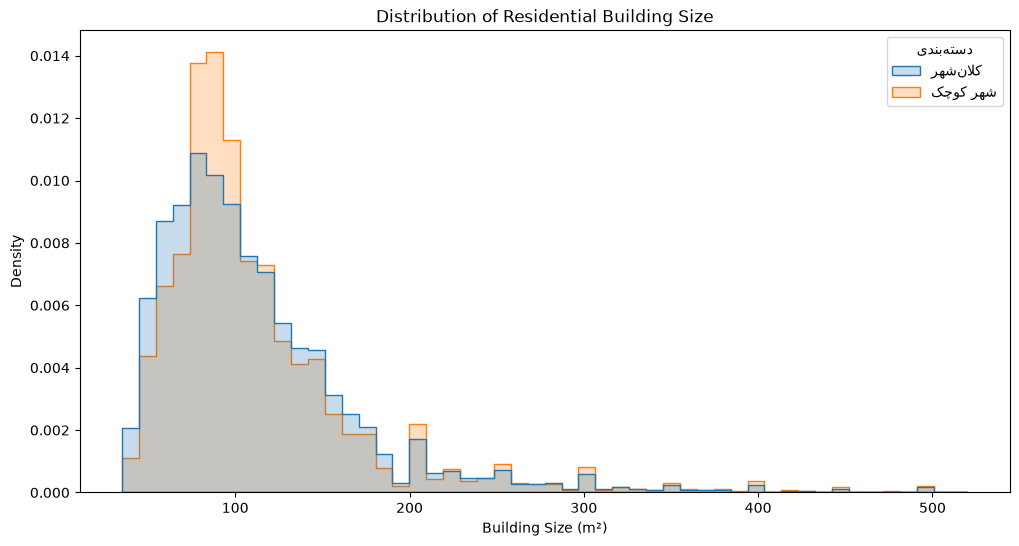

In [23]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=plot_data,
    x="building_size",
    hue="دسته‌بندی",
    stat="density",
    common_norm=False,
    bins=50,
    element="step"
)

plt.title("Distribution of Residential Building Size")
plt.xlabel("Building Size (m²)")
plt.ylabel("Density")

plt.show()

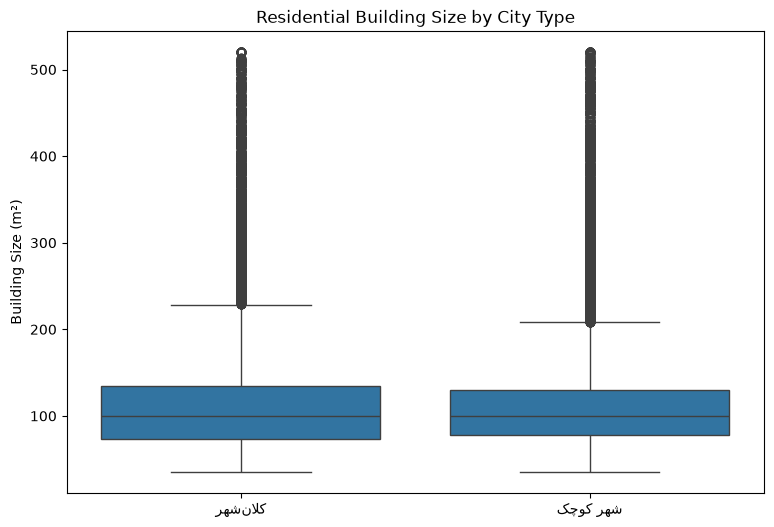

In [24]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=plot_data,
    x="دسته‌بندی",
    y="building_size"
)

plt.title("Residential Building Size by City Type")
plt.xlabel("")
plt.ylabel("Building Size (m²)")

plt.show()

In [25]:
analysis_data = analysis_data[
    analysis_data["building_size"].between(35, 1500)
]
analysis_data.shape

(676036, 4)

##### هر آگهی یک Observation

In [26]:
metro_ads = analysis_data.loc[
    analysis_data["دسته‌بندی"] == "کلان‌شهر",
    "building_size"
]

small_city_ads = analysis_data.loc[
    analysis_data["دسته‌بندی"] == "شهر کوچک",
    "building_size"
]

print("Metropolis:")
print("n =", len(metro_ads))
print("mean =", metro_ads.mean())
print("median =", metro_ads.median())
print("std =", metro_ads.std())

print("\nSmall city:")
print("n =", len(small_city_ads))
print("mean =", small_city_ads.mean())
print("median =", small_city_ads.median())
print("std =", small_city_ads.std())

Metropolis:
n = 354531
mean = 116.96096533166352
median = 100.0
std = 84.82321749937435

Small city:
n = 321505
mean = 118.8649632198566
median = 100.0
std = 85.743715500711


In [27]:
mean_summary = (
    analysis_data
    .groupby("دسته‌بندی")["building_size"]
    .agg(["count", "mean", "std"])
)

mean_summary["se"] = (
    mean_summary["std"] / mean_summary["count"] ** 0.5
)

mean_summary["ci_95"] = (
    1.96 * mean_summary["se"]
)

mean_summary

,count,mean,std,se,ci_95
دسته‌بندی,,,,,
شهر کوچک,321505,118.864963,85.743716,0.151220,0.296391
کلان‌شهر,354531,116.960965,84.823217,0.142458,0.279218


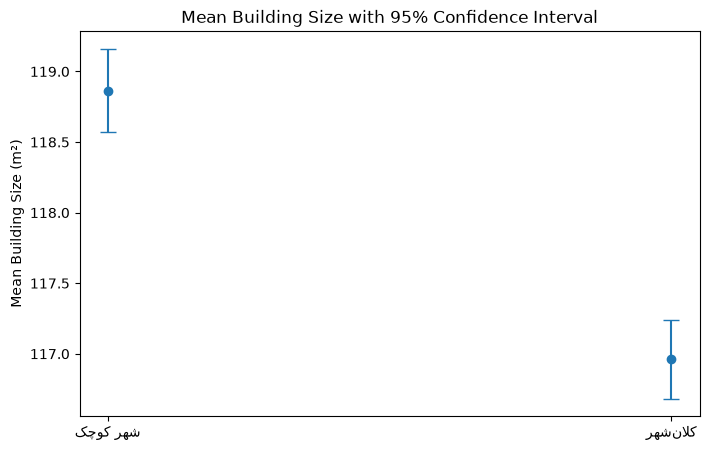

In [28]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    x=mean_summary.index,
    y=mean_summary["mean"],
    yerr=mean_summary["ci_95"],
    fmt="o",
    capsize=6
)

plt.title("Mean Building Size with 95% Confidence Interval")
plt.xlabel("")
plt.ylabel("Mean Building Size (m²)")

plt.show()

In [29]:
t_stat, p_value = stats.ttest_ind(
    metro_ads,
    small_city_ads,
    equal_var=False,
    alternative="less"
)

print("H0: μ_metro >= μ_small")
print("H1: μ_metro < μ_small")

print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.3e}")

H0: μ_metro >= μ_small
H1: μ_metro < μ_small

t-statistic: -9.1647
p-value: 2.492e-20


In [30]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print(
        "There is sufficient evidence that "
        "the mean building size in metropolises "
        "is lower than in small cities."
    )
else:
    print("Fail to reject H0")
    print(
        "There is not enough evidence that "
        "the mean building size in metropolises "
        "is lower than in small cities."
    )

Reject H0
There is sufficient evidence that the mean building size in metropolises is lower than in small cities.


##### هر شهر یک Observation

In [31]:
city_level = (
    analysis_data
    .groupby(
        ["city_slug", "دسته‌بندی"],
        as_index=False
    )
    .agg(
        mean_building_size=("building_size", "mean"),
        ads_count=("building_size", "count")
    )
)

city_level.head()

,city_slug,دسته‌بندی,mean_building_size,ads_count
0,Iranshahr,شهر کوچک,163.490476,420
1,Kordkuy,شهر کوچک,112.037634,186
2,abadan,شهر کوچک,124.498960,1924
3,abadeh,شهر کوچک,149.606061,297
4,abbasabad-mazandaran,شهر کوچک,168.100000,250


In [32]:
city_level["دسته‌بندی"].value_counts()

دسته‌بندی
شهر کوچک    231
کلان‌شهر      9
Name: count, dtype: int64

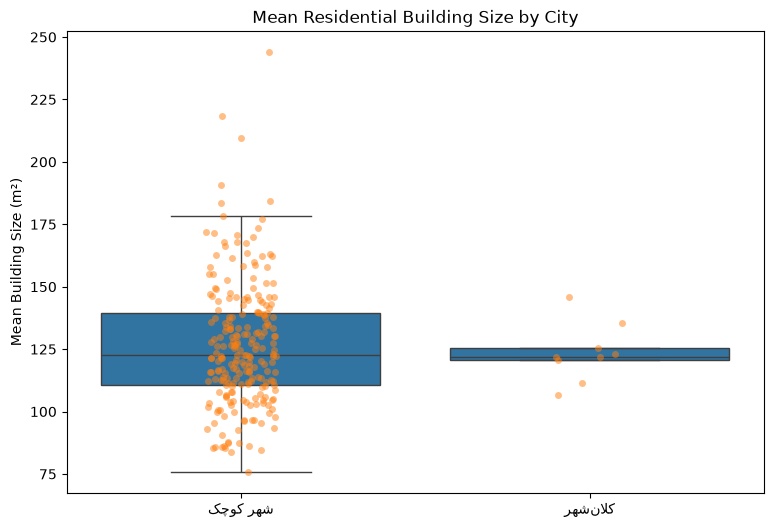

In [33]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=city_level,
    x="دسته‌بندی",
    y="mean_building_size",
    showfliers=False
)

sns.stripplot(
    data=city_level,
    x="دسته‌بندی",
    y="mean_building_size",
    jitter=True,
    alpha=0.5
)

plt.title("Mean Residential Building Size by City")
plt.xlabel("")
plt.ylabel("Mean Building Size (m²)")

plt.show()

In [34]:
metro_cities = city_level.loc[
    city_level["دسته‌بندی"] == "کلان‌شهر",
    "mean_building_size"
]

small_cities = city_level.loc[
    city_level["دسته‌بندی"] == "شهر کوچک",
    "mean_building_size"
]

print("Metropolis n:", len(metro_cities))
print("Small city n:", len(small_cities))

Metropolis n: 9
Small city n: 231


In [35]:
metro_shapiro = stats.shapiro(metro_cities)
small_shapiro = stats.shapiro(small_cities)

print("Shapiro-Wilk Normality Test")

print(
    f"Metropolis p-value: "
    f"{metro_shapiro.pvalue:.4f}"
)

print(
    f"Small cities p-value: "
    f"{small_shapiro.pvalue:.4f}"
)

Shapiro-Wilk Normality Test
Metropolis p-value: 0.5252
Small cities p-value: 0.0000


با 9 تا نمونه خب معلوم بود میگه نرمال نیست

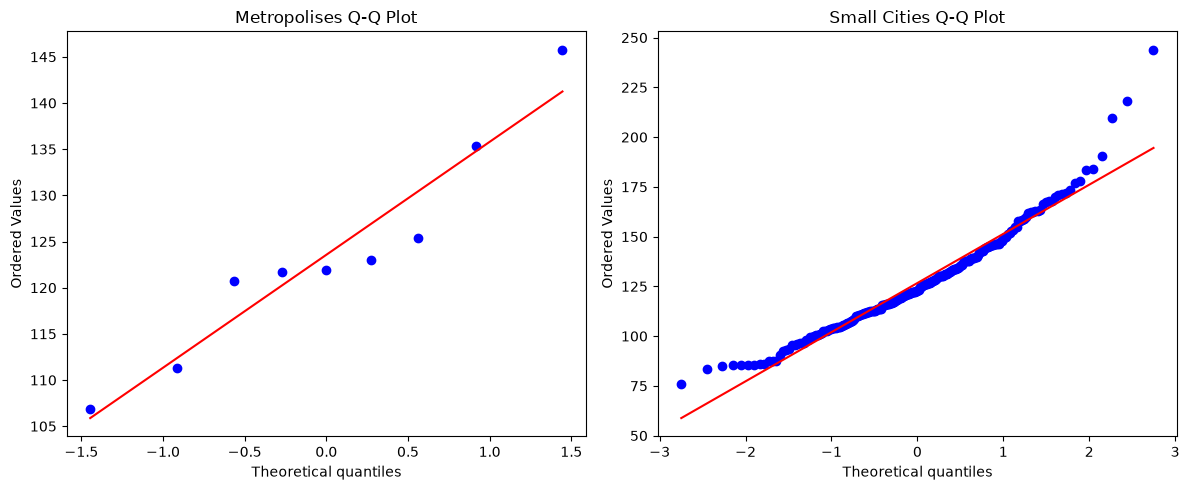

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(
    metro_cities,
    dist="norm",
    plot=axes[0]
)

axes[0].set_title("Metropolises Q-Q Plot")

stats.probplot(
    small_cities,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title("Small Cities Q-Q Plot")

plt.tight_layout()
plt.show()

In [37]:
alpha = 0.05
test_name = "Mann-Whitney U Test" #ranking

statistic, p_value_city = stats.mannwhitneyu(
    metro_cities,
    small_cities,
    alternative="less"
)

print("Selected test:", test_name)
print(f"Statistic: {statistic:.4f}")
print(f"p-value: {p_value_city:.3e}")

if p_value_city < alpha:
    print("Reject H0")
    
    if test_name == "Welch Two-Sample t-Test":
        print(
            "There is sufficient evidence that "
            "metropolises have a lower mean "
            "of city-level average building sizes."
        )
        
    else:
        print(
            "There is sufficient evidence that "
            "metropolises tend to have lower "
            "city-level average building sizes "
            "than small cities."
        )

else:
    print("Fail to reject H0")
    print(
        "There is not enough evidence to support "
        "the claim that metropolises have smaller "
        "city-level average building sizes."
    )

Selected test: Mann-Whitney U Test
Statistic: 1014.0000
p-value: 4.513e-01
Fail to reject H0
There is not enough evidence to support the claim that metropolises have smaller city-level average building sizes.
